In [1]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import esmpy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
grid_src = esmpy.Grid(filename='src_grid.nc', filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=False)
grid_dst = esmpy.Grid(filename='dst_grid.nc', filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=False)

field_src = esmpy.Field(grid_src, staggerloc=esmpy.StaggerLoc.CENTER, ndbounds=[37,])
field_dst = esmpy.Field(grid_dst, staggerloc=esmpy.StaggerLoc.CENTER, ndbounds=[37,])

regrid_src2dst = esmpy.Regrid(
    field_src,
    field_dst,
    regrid_method=esmpy.RegridMethod.BILINEAR,
    unmapped_action=esmpy.UnmappedAction.IGNORE
)

In [3]:
# Define bounding box limits - ERA5 data over ROMS grid
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

vars = {
    "10u"  : "u10",
    "10v"  : "v10",
    "msl"  : "msl",
    "2t"   : "t2m",
    "2rh"  : "rh2",
    "tp"   : "tp",
    "lwdn" : "strd",
    "swnet": "ssr",
}

data_path = '/glade/derecho/scratch/turuncu/data/Data_aurora'
files_pred = sorted(glob.glob(os.path.join(data_path, "predictions_irene_tp", "pred_*.nc")))
files_input = sorted(glob.glob(os.path.join(data_path, "split_files", "data_*.nc")))

In [4]:
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

In [38]:
for f in files_pred:
    print('Processing ', f, os.path.basename(f)[5:-3])
    date_str = os.path.basename(f)[5:-3]

    # Create datasets
    ds_aurora_interp = xr.Dataset()
    ds_era5_interp = xr.Dataset()

    # Load prediction dataset
    ds_aurora = xr.open_dataset(f)[list(vars.keys())]
    ds_aurora = ds_aurora.load().reindex(latitude=ds_aurora.latitude[::-1])
    ds_aurora_subset = ds_aurora.sel(batch=0, longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))
    ds_aurora_subset.to_netcdf(f"pred_{date_str}_subset.nc")

    # Get time information
    time_pred = ds_aurora_subset.time.values

    # Load ground truth - ERA5
    ds_era5 = xr.open_mfdataset(files_input, data_vars='all')
    ds_era5 = ds_era5.sel(time=time_pred)
    ds_era5 = ds_era5.load().reindex(latitude=ds_era5.latitude[::-1])
    ds_era5_subset = ds_era5.sel(longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))[list(vars.values())]
    ds_era5_subset.to_netcdf(f"data_{date_str}_subset.nc")

    # Loop over prediction/ground truth variables and interpolate them to ROMS grid
    for v in ds_aurora.data_vars.keys():
        # Fill fields and perform interpolation for predictions
        field_src.data[:] = ds_aurora_subset[v].transpose().values
        field_dst.data[:] = 1e20
        field_dst = regrid_src2dst(field_src, field_dst, zero_region=esmpy.Region.SELECT)

        # Add result to new dataset
        ds_aurora_interp[v] = xr.DataArray(
            field_dst.data[:].transpose().copy(),
            dims = {
                'lead_time': time_pred,
                'eta_rho': grid.eta_rho,
                'xi_rho': grid.xi_rho,
            }
        ).assign_coords(time=time_pred[0]).expand_dims("time")

        # Fill fields and perform interpolation for predictions
        field_dst.data[:] = 1e20
        field_src.data[:] = ds_era5_subset[vars[v]].transpose().values
        field_dst = regrid_src2dst(field_src, field_dst, zero_region=esmpy.Region.SELECT)

        # Add result to new dataset
        ds_era5_interp[v] = xr.DataArray(
            field_dst.data[:].transpose().copy(),
            dims = {
                'lead_time': time_pred,
                'eta_rho': grid.eta_rho,
                'xi_rho': grid.xi_rho,
            }
        ).assign_coords(time=time_pred[0]).expand_dims("time")

    # Write interpolated data
    ds_aurora_interp.to_netcdf(f"pred_{date_str}_interp.nc")
    ds_era5_interp.to_netcdf(f"data_{date_str}_interp.nc")

Processing  /glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene_tp/pred_2011-08-21T12:00:00.nc 2011-08-21T12:00:00


ValueError: could not broadcast input array from shape (161,121,37) into shape (2880,1440,37)

In [ ]:
# List files
data_path = './'
files_pred = sorted(glob.glob(os.path.join(data_path, "pred_*_subset.nc")))
files_input = sorted(glob.glob(os.path.join(data_path, "data_*_subset.nc")))

# Calculate statistics
data_list = []
for f_pred, f_target in zip(files_pred, files_input):
    # Open files
    ds_pred = xr.open_dataset(f_pred)
    ds_target = xr.open_dataset(f_target)

    # Get dimensions
    ntime = ds_pred.time.shape[0]
    nlat = ds_pred.latitude.shape[0]
    nlon = ds_pred.longitude.shape[0]

    for v in ds_pred.data_vars.keys():
        # Get variable
        data_pred = ds_pred[v]
        data_target = ds_target[vars[v]]
        # Apply unit conversion if it is required
        if v in ["lwdn", "swnet", "tp"]:
            data_target = data_target/3600.0
        # Calculate correlation and RMSE
        rmse = np.sqrt((data_pred - data_target)**2)
        nrmse = rmse/(data_target.max() - data_target.min())
        rmse_avg = rmse.mean(['latitude', 'longitude'])
        nrmse_avg = nrmse.mean(['latitude', 'longitude'])
        corr = xr.corr(data_pred, data_target, dim=['latitude', 'longitude'])

        # Add results to data list
        for r in list(np.arange(0, ntime, 1)):
            data_list.append(
                {
                    "time": ds_pred[v].time.values[0],
                    "variable": v,
                    "rollout_step": r,
                    "rmse": rmse_avg.values[r],
                    "nrmse": nrmse_avg.values[r],
                    "corr": corr.values[r]
                }
            )

# Convert to data frame
df = pd.DataFrame.from_records(data_list)
df = df.set_index(["time", "variable", "rollout_step"])

# Convert to dataset
ds = xr.Dataset.from_dataframe(df)
if os.path.exists("stats_subset.nc"):
    os.remove("stats_subset.nc")
ds.to_netcdf("stats_subset.nc")

In [94]:
# List files
data_path = './'
files_pred = sorted(glob.glob(os.path.join(data_path, "pred_*_interp.nc")))
files_input = sorted(glob.glob(os.path.join(data_path, "data_*_interp.nc")))

# Calculate statistics
data_list = []
for f_pred, f_target in zip(files_pred, files_input):
    # Open files
    ds_pred = xr.open_dataset(f_pred)
    ds_target = xr.open_dataset(f_target)

    # Get dimensions
    ntime = ds_pred.lead_time.shape[0]
    nlat = ds_pred.eta_rho.shape[0]
    nlon = ds_pred.xi_rho.shape[0]

    for v in ds_pred.data_vars.keys():
        # Get variable
        data_pred = ds_pred[v].isel(time=0)
        data_target = ds_target[v].isel(time=0)
        # Apply unit conversion if it is required
        if v in ["lwdn", "swnet", "tp"]:
            data_target = data_target/3600.0
        # Calculate correlation and RMSE
        rmse = np.sqrt((data_pred - data_target)**2)
        nrmse = rmse/(data_target.max() - data_target.min())
        rmse_avg = rmse.mean(['eta_rho', 'xi_rho'])
        nrmse_avg = nrmse.mean(['eta_rho', 'xi_rho'])
        corr = xr.corr(data_pred, data_target, dim=['eta_rho', 'xi_rho'])

        # Add results to data list
        for r in list(np.arange(0, ntime, 1)):
            data_list.append(
                {
                    "time": ds_pred[v].time.values[0],
                    "variable": v,
                    "rollout_step": r,
                    "rmse": rmse_avg.values[r],
                    "nrmse": nrmse_avg.values[r],
                    "corr": corr.values[r]
                }
            )

# Convert to data frame
df = pd.DataFrame.from_records(data_list)
df = df.set_index(["time", "variable", "rollout_step"])

# Convert to dataset
ds = xr.Dataset.from_dataframe(df)
if os.path.exists("stats_interp.nc"):
    os.remove("stats_interp.nc")
ds.to_netcdf("stats_interp.nc")

In [2]:
ds_stat_subset = xr.open_dataset("stats_subset.nc")
ds_stat_interp = xr.open_dataset("stats_interp.nc")

variables = ds_stat_subset.variable.values
rollout_step = ds_stat_subset.rollout_step.values

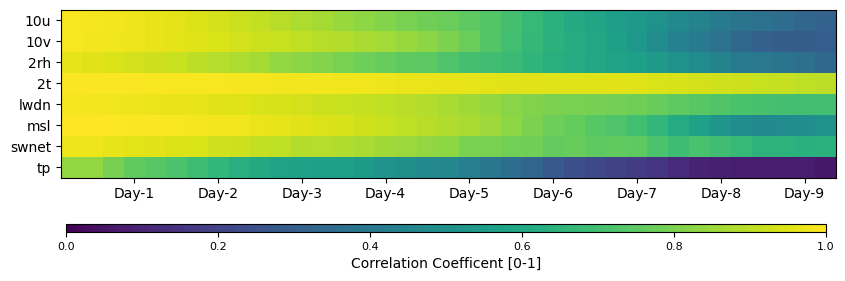

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))

im = ax.imshow(ds_stat_subset.corr.mean(["time"]), cmap="viridis", vmin=0, vmax=1)
x = [f"Day-{int(r)}" for r in (rollout_step[3::4]+1)/4]
ax.set_xticks(range(len(rollout_step))[3::4], labels=x, fontsize=10)
ax.set_yticks(range(len(variables)), labels=variables, fontsize=10)

fig.subplots_adjust(hspace=0.02, wspace=0.0)

#cbar_ax = fig.add_axes([0.92, 0.285, 0.01, 0.42])
#fig.colorbar(ax.images[0], cax=cbar_ax, label='Correlation [0-1]')
cbar_ax = fig.add_axes([0.13, 0.15, 0.76, 0.02])
cbar_ax.tick_params(labelsize=8)
fig.colorbar(ax.images[0], cax=cbar_ax, label='Correlation Coefficent [0-1]', orientation='horizontal')

plt.savefig("regional_correlation_single.png", bbox_inches='tight', pad_inches=0.6, dpi=300)

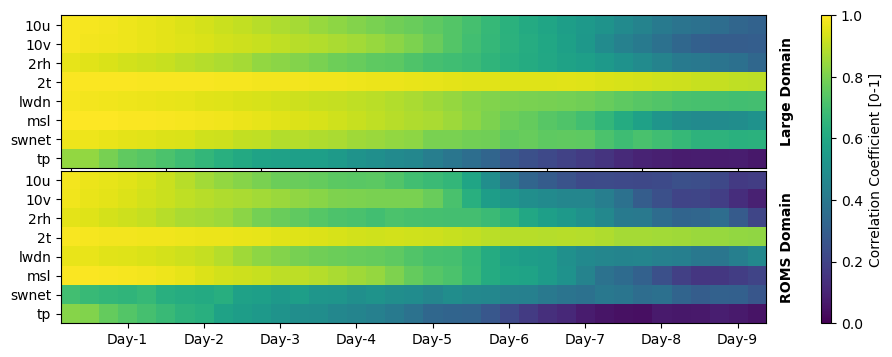

In [82]:
ds_stat_subset = xr.open_dataset("stats_subset.nc")
ds_stat_interp = xr.open_dataset("stats_interp.nc")

variables = ds_stat_subset.variable.values
rollout_step = ds_stat_subset.rollout_step.values

fig, ax = plt.subplots(2, 1, figsize=(10,4))

im0 = ax[0].imshow(ds_stat_subset.corr.mean(["time"]), cmap="viridis", vmin=0, vmax=1)
y = [f"Day-{int(r)}" for r in (rollout_step[3::4]+1)/4]
ax[0].set_xticklabels([])
ax[0].set_xlabel('')
ax[0].set_yticks(range(len(variables)), labels=variables, fontsize=10)
text = ax[0].text(1.03, 0.5, "Large Domain", ha="center", va="center", fontweight='bold', fontsize=10, color="black", rotation=90, transform=ax[0].transAxes)

im1 = ax[1].imshow(ds_stat_interp.corr.mean(["time"]), cmap="viridis", vmin=0, vmax=1)
x = [f"Day-{int(r)}" for r in (rollout_step[3::4]+1)/4]
ax[1].set_xticks(range(len(rollout_step))[3::4], labels=x, fontsize=10)
ax[1].set_yticks(range(len(variables)), labels=variables, fontsize=10)
text = ax[1].text(1.03, 0.5, "ROMS Domain", ha="center", va="center", fontweight='bold', fontsize=10, color="black", rotation=90, transform=ax[1].transAxes)

fig.subplots_adjust(hspace=0.02, wspace=0.0)

cbar_ax = fig.add_axes([0.92, 0.11, 0.01, 0.77])
fig.colorbar(ax[0].images[0], cax=cbar_ax, label='Correlation Coefficient [0-1]')
plt.savefig("regional_correlation.png", bbox_inches='tight', pad_inches=0.6, dpi=300)

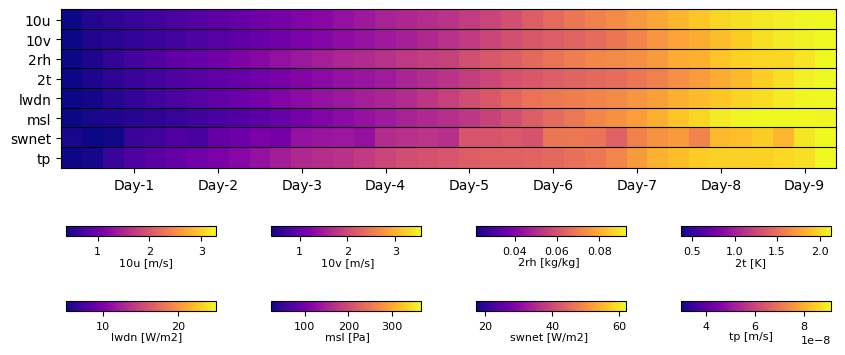

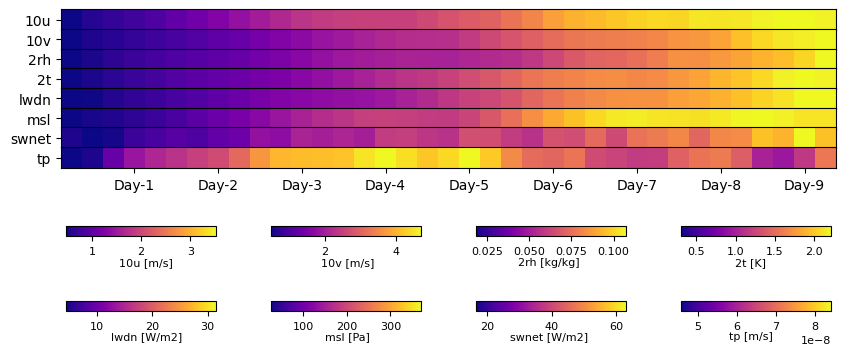

In [15]:
ds_stat_subset = xr.open_dataset("stats_subset.nc")
ds_stat_interp = xr.open_dataset("stats_interp.nc")

variables = ds_stat_subset.variable.values
rollout_step = ds_stat_subset.rollout_step.values

fig, ax = plt.subplots(len(variables), 1, figsize=(10,5))#, gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

i = 0
for v in variables:
    data = ds_stat_subset.rmse.sel(variable=v).mean(["time"]).values[None]
    im = ax[i].imshow(data, cmap='plasma')
    ax[i].set_yticks([0])
    ax[i].set_yticklabels([v], fontsize=10)
    if i == len(variables)-1:
        x = [f"Day-{int(r)}" for r in (rollout_step[3::4]+1)/4]
        ax[i].set_xticks(range(len(rollout_step))[3::4], labels=x, fontsize=10)
    else:
        ax[i].set_xticklabels([])
        ax[i].set_xlabel('')
    if i < 4:
        cbar_ax = fig.add_axes([0.13+i*0.205, 0.2, 0.15, 0.02])
    else:
        cbar_ax = fig.add_axes([0.13+(i%4)*0.205, 0.05, 0.15, 0.02])
    cbar_ax.tick_params(labelsize=8)
    fig.colorbar(ax[i].images[0], cax=cbar_ax, label='', orientation='horizontal')
    if v in ['10u', '10v']:
        unit = 'm/s'
    if v in ['lwdn', 'swnet']:
        unit = 'W/m2'
    if v == '2t':
        unit = 'K'
    if v == '2rh':
        unit = 'kg/kg'
    if v == 'msl':
        unit = 'Pa'
    if v == 'tp':
        unit = 'm/s'
    if i < 4:
        text = ax[-1].text(0.11+i*0.26, -4.5, f"{v} [{unit}]", ha="center", va="center", fontsize=8, color="black", transform=ax[-1].transAxes)
    else:
        text = ax[-1].text(0.11+(i%4)*0.26, -8.0, f"{v} [{unit}]", ha="center", va="center", fontsize=8, color="black", transform=ax[-1].transAxes)
    if v == 'tp':
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        cbar_ax.formatter = formatter
        t = cbar_ax.xaxis.get_offset_text()
        t.set_size(8)
    i = i+1

fig.subplots_adjust(hspace=-0.92, wspace=-0.5)
plt.savefig("regional_rmse.png", bbox_inches='tight', pad_inches=0.6, dpi=300)

fig, ax = plt.subplots(len(variables), 1, figsize=(10,5))#, gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

i = 0
for v in variables:
    data = ds_stat_interp.rmse.sel(variable=v).mean(["time"]).values[None]
    im = ax[i].imshow(data, cmap='plasma')
    ax[i].set_yticks([0])
    ax[i].set_yticklabels([v], fontsize=10)
    if i == len(variables)-1:
        x = [f"Day-{int(r)}" for r in (rollout_step[3::4]+1)/4]
        ax[i].set_xticks(range(len(rollout_step))[3::4], labels=x, fontsize=10)
    else:
        ax[i].set_xticklabels([])
        ax[i].set_xlabel('')
    if i < 4:
        cbar_ax = fig.add_axes([0.13+i*0.205, 0.2, 0.15, 0.02])
    else:
        cbar_ax = fig.add_axes([0.13+(i%4)*0.205, 0.05, 0.15, 0.02])
    cbar_ax.tick_params(labelsize=8)
    fig.colorbar(ax[i].images[0], cax=cbar_ax, label='', orientation='horizontal')
    if v in ['10u', '10v']:
        unit = 'm/s'
    if v in ['lwdn', 'swnet']:
        unit = 'W/m2'
    if v == '2t':
        unit = 'K'
    if v == '2rh':
        unit = 'kg/kg'
    if v == 'msl':
        unit = 'Pa'
    if v == 'tp':
        unit = 'm/s'
    if i < 4:
        text = ax[-1].text(0.11+i*0.26, -4.5, f"{v} [{unit}]", ha="center", va="center", fontsize=8, color="black", transform=ax[-1].transAxes)
    else:
        text = ax[-1].text(0.11+(i%4)*0.26, -8.0, f"{v} [{unit}]", ha="center", va="center", fontsize=8, color="black", transform=ax[-1].transAxes)
    if v == 'tp':
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        cbar_ax.formatter = formatter
        t = cbar_ax.xaxis.get_offset_text()
        t.set_size(8)
    i = i+1

fig.subplots_adjust(hspace=-0.92, wspace=-0.5)
plt.savefig("regional_roms_rmse.png", bbox_inches='tight', pad_inches=0.6, dpi=300)

In [17]:
# Define bounding box limits - ERA5 data over ROMS grid
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# List of variables used for coupling
vars = {
    "10u"  : "u10",
    "10v"  : "v10",
    "msl"  : "msl",
    "2t"   : "t2m",
    "2rh"  : "rh2",
    "tp"   : "tp",
    "lwdn" : "strd",
    "swnet": "ssr",
}

# Load statistics
ds_stats = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Data_aurora/prediction_stats_irene_tp/stat_surface_2d.nc')
ds_stats = ds_stats.reindex(latitude=ds_stats.latitude[::-1])
ds_stats_subset = ds_stats.sel(longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))
ds_stats_subset.to_netcdf("stat_surface_2d_subset.nc")

# Read source and destination grid
data_path = '/glade/campaign/cgd/projects/ai_coupling/Data_aurora/prediction_stats_irene_tp'
grid_src = esmpy.Grid(filename=os.path.join(data_path, 'src_grid.nc'), filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=False)
grid_dst = esmpy.Grid(filename=os.path.join(data_path, 'dst_grid.nc'), filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=False)

ntime = ds_stats_subset.time.shape[0]
nrollout_step = ds_stats_subset.rollout_step.shape[0]
field_src = esmpy.Field(grid_src, staggerloc=esmpy.StaggerLoc.CENTER, ndbounds=[ntime,nrollout_step,])
field_dst = esmpy.Field(grid_dst, staggerloc=esmpy.StaggerLoc.CENTER, ndbounds=[ntime,nrollout_step,])

regrid_src2dst = esmpy.Regrid(
    field_src,
    field_dst,
    regrid_method=esmpy.RegridMethod.BILINEAR,
    unmapped_action=esmpy.UnmappedAction.IGNORE
)

# Loop over prediction/ground truth variables and interpolate them to ROMS grid
ds_stats_subset_interp = xr.Dataset()

for v in ds_stats_subset.data_vars.keys():
    # Fill fields and perform interpolation for predictions
    field_src.data[:] = ds_stats_subset[v].transpose().values
    field_dst.data[:] = 1e20
    field_dst = regrid_src2dst(field_src, field_dst, zero_region=esmpy.Region.SELECT)

    # Add result to new dataset
    ds_stats_subset_interp[v] = xr.DataArray(
        field_dst.data[:].transpose().copy(),
        dims = {
            'lead_time': time_pred,
            'eta_rho': grid.eta_rho,
            'xi_rho': grid.xi_rho,
        }
    ).assign_coords(time=time_pred[0]).expand_dims("time")

# Write interpolated data
ds_stats_subset_interp.to_netcdf("stat_surface_2d_interp.nc")

ValueError: could not broadcast input array from shape (161,121,35) into shape (1440,720,35,37)

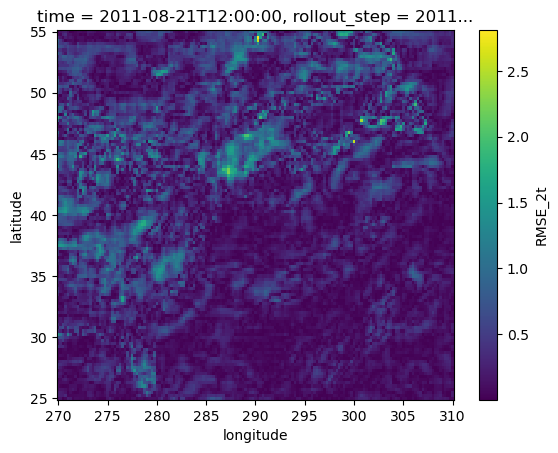

In [10]:
ds_stats_subset.RMSE_2t.isel(time=0, rollout_step=0).plot()

AttributeError: 'Axes' object has no attribute 'set_extent'

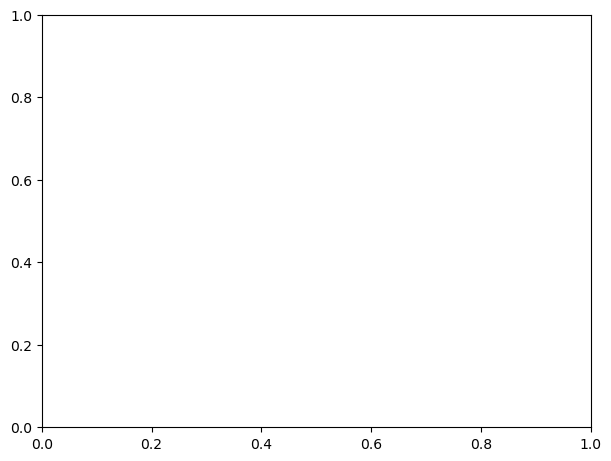

In [19]:
# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Plot data
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')#, subplot_kw={'projection': projection})

# Add coastline etc.
#ax.add_feature(cfeature.COASTLINE, alpha=0.4)
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
#ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
#ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Observation
data = ds_stats_subset.RMSE_2t.isel(time=0, rollout_step=0)
#im = ax.pcolormesh(ds_stats_subset.longitude, ds_stats_subset.latitude, data, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())

(x="lon_rho", y="lat_rho")